In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from notebook_utils import bootstrap_mean_and_ci

In [2]:
with open(f"../scripts/_cache/stability_vs_smoothing_resnet18_imagenet_2_per_class.json") as f:
    resnet18_saved = json.load(f)

with open(f"../scripts/_cache/stability_vs_smoothing_resnet50_imagenet_2_per_class.json") as f:
    resnet50_saved = json.load(f)

with open(f"../scripts/_cache/stability_vs_smoothing_vit_imagenet_2_per_class.json") as f:
    vit_saved = json.load(f)

with open(f"../scripts/_cache/stability_vs_smoothing_roberta_tweeteval_sentiment.json") as f:
    roberta_saved = json.load(f)

In [8]:
def make_plot(saved, title, radii=None, xticks=None, legend_loc=None, fs=14):
    lambda_to_rates = saved["lambda_to_rates"]
    radius_inds = [saved["radii"].index(r) for r in radii]

    fig, ax = plt.subplots(figsize=(4,3))
    for lam in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
        all_curves = np.array(lambda_to_rates[f"{lam:.3f}"])
        all_curves = all_curves[:,radius_inds]
        mean, lb, ub = bootstrap_mean_and_ci(all_curves, ci=95)
        ax.plot(radii, mean, label=f"$\lambda = {lam:.1f}$")
        ax.fill_between(radii, lb, ub, alpha=0.2)

    ax.set_ylabel("Stability Rate", fontsize=fs)
    ax.set_xlabel(f"({title}) Pert Radius", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs)
    if xticks is not None:
        ax.set_xticks(xticks)

    # title = None
    ax.legend(
        # title=title,
        loc=legend_loc,
        title_fontsize=fs,
        fontsize=fs-2,
        ncol=1,
    )
    return fig

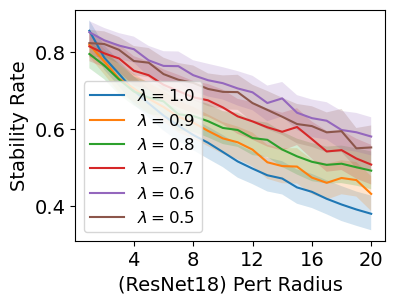

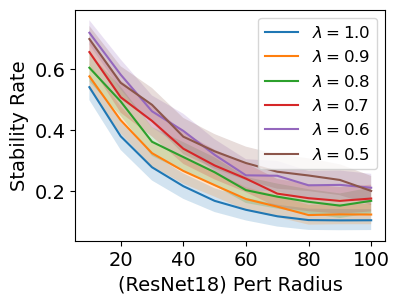

In [9]:
fig = make_plot(resnet18_saved, "ResNet18", radii=list(range(1,21)), xticks=[4, 8, 12, 16, 20])
fig.savefig("_dump/stability_vs_smoothing_resnet18_small.pdf", bbox_inches="tight")
fig = make_plot(resnet18_saved, "ResNet18", radii=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100], xticks=[20, 40, 60, 80, 100])
fig.savefig("_dump/stability_vs_smoothing_resnet18_big.pdf", bbox_inches="tight")

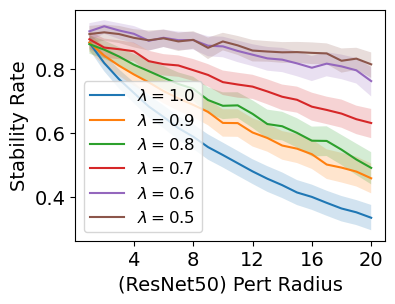

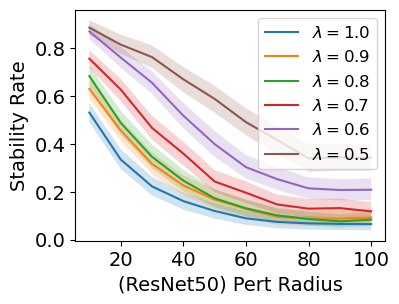

In [10]:
fig = make_plot(resnet50_saved, "ResNet50", radii=list(range(1,21)), xticks=[4, 8, 12, 16, 20])
fig.savefig("_dump/stability_vs_smoothing_resnet50_small.pdf", bbox_inches="tight")
fig = make_plot(resnet50_saved, "ResNet50", radii=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100], xticks=[20, 40, 60, 80, 100])
fig.savefig("_dump/stability_vs_smoothing_resnet50_big.pdf", bbox_inches="tight")

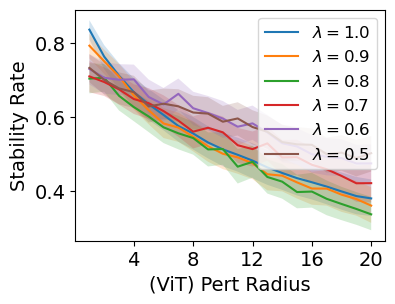

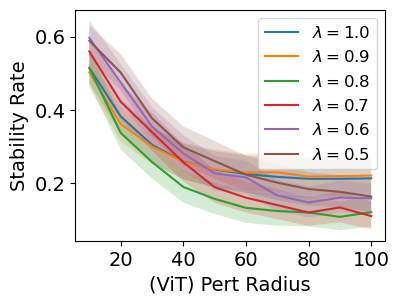

In [11]:
fig = make_plot(vit_saved, "ViT", radii=list(range(1,21)), xticks=[4, 8, 12, 16, 20])
fig.savefig("_dump/stability_vs_smoothing_vit_small.pdf", bbox_inches="tight")
fig = make_plot(vit_saved, "ViT", radii=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100], xticks=[20, 40, 60, 80, 100])
fig.savefig("_dump/stability_vs_smoothing_vit_big.pdf", bbox_inches="tight")

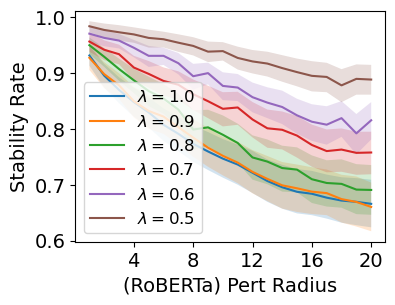

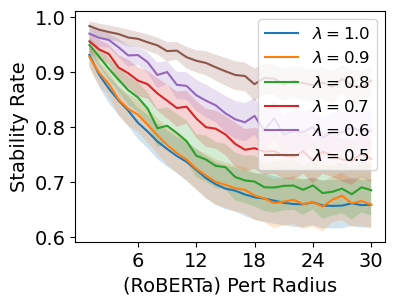

In [12]:
fig = make_plot(roberta_saved, "RoBERTa", radii=list(range(1,21)), xticks=[4, 8, 12, 16, 20])
fig.savefig("_dump/stability_vs_smoothing_roberta_small.pdf", bbox_inches="tight")
fig = make_plot(roberta_saved, "RoBERTa", radii=list(range(1,31)), xticks=[6, 12, 18, 24, 30])
fig.savefig("_dump/stability_vs_smoothing_roberta_big.pdf", bbox_inches="tight")